In [1]:
! pip install lpips

In [2]:
import os
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import layers 
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
import random
import tensorflow as tf
import glob as glob_module
from tqdm.notebook import tqdm
import os
from IPython.display import clear_output
from tabulate import tabulate
from matplotlib import gridspec
import numpy as np
import tensorflow as tf
from scipy import linalg
from sklearn.metrics.pairwise import polynomial_kernel
from skimage.metrics import structural_similarity as ssim
import lpips
import torch
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline

2026-04-07 15:51:16.306572: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775577076.330194    3926 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775577076.337657    3926 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775577076.357064    3926 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775577076.357092    3926 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775577076.357094    3926 computation_placer.cc:177] computation placer alr

In [3]:
SEED = 123

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

tf.config.experimental.enable_op_determinism()

print("Random seeds set for reproducibility.")
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

Random seeds set for reproducibility.
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
DATA_ROOT="/kaggle/input/datasets/wchowdhu/bengali-digits/bengali_digits"

LATENT_DIM = 100
IMG_SIZE = 28
IMG_FLAT = 28 * 28 * 1
HIDDEN_DIM = 256
BATCH_SIZE = 128
LR_G = 0.0005
LR_D = 0.0002
EPOCHS = 200
AUTOTUNE   = tf.data.AUTOTUNE

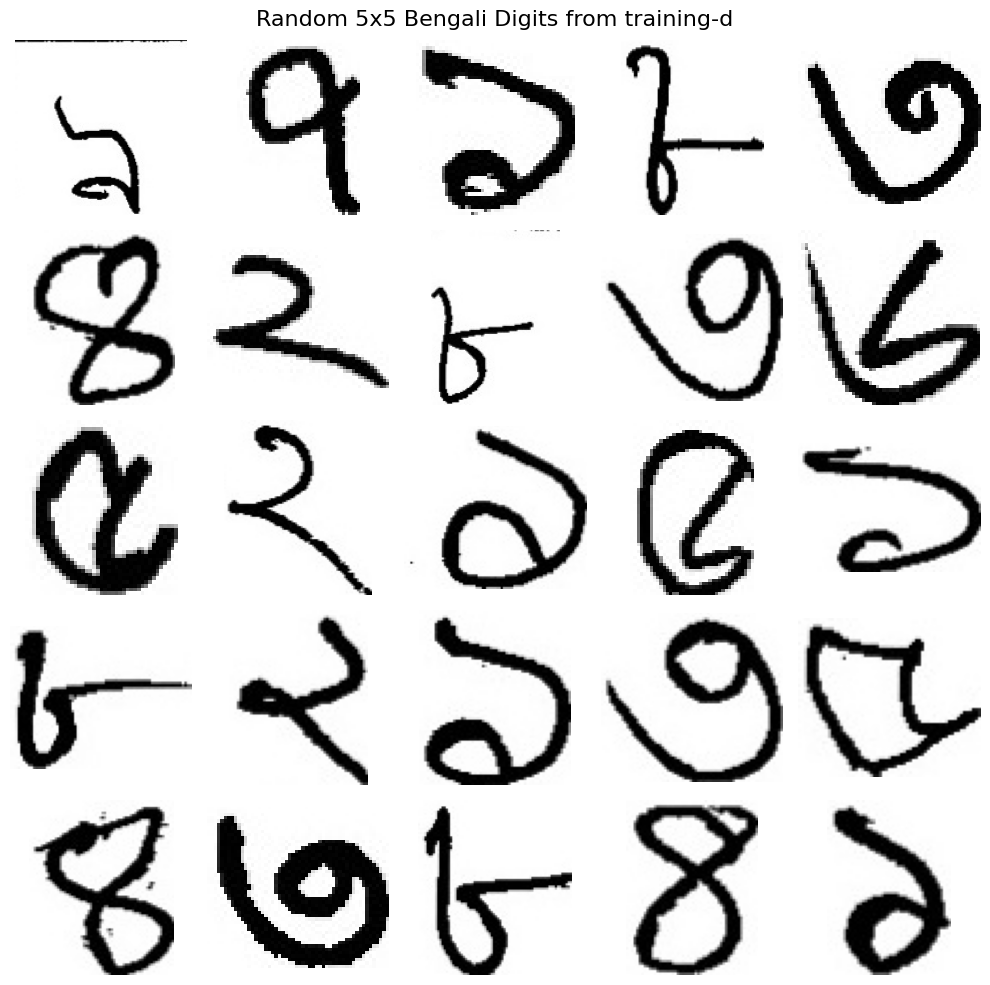

In [5]:
# Get all image paths
image_paths = []
for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            image_paths.append(os.path.join(root, file))

# Shuffle and select 25 images
random.shuffle(image_paths)
selected_images = image_paths[:25]

# Plot 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle("Random 5x5 Bengali Digits from training-d", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(selected_images):
        img = Image.open(selected_images[i])
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
def preprocess(image):
    return (tf.cast(image, tf.float32) / 127.5) - 1.0

dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    labels=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

dataset = dataset.map(preprocess).prefetch(AUTOTUNE)

Found 15620 files.


I0000 00:00:1775577117.094606    3926 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
for batch in dataset.take(1):
    print("Batch shape :", batch.shape)
    print("Min / Max   :", batch.numpy().min(), "/", batch.numpy().max())

Batch shape : (128, 28, 28, 1)
Min / Max   : -1.0 / 1.0


Batch shape : (128, 28, 28, 1)
Min / Max   : -1.0000 / 1.0000


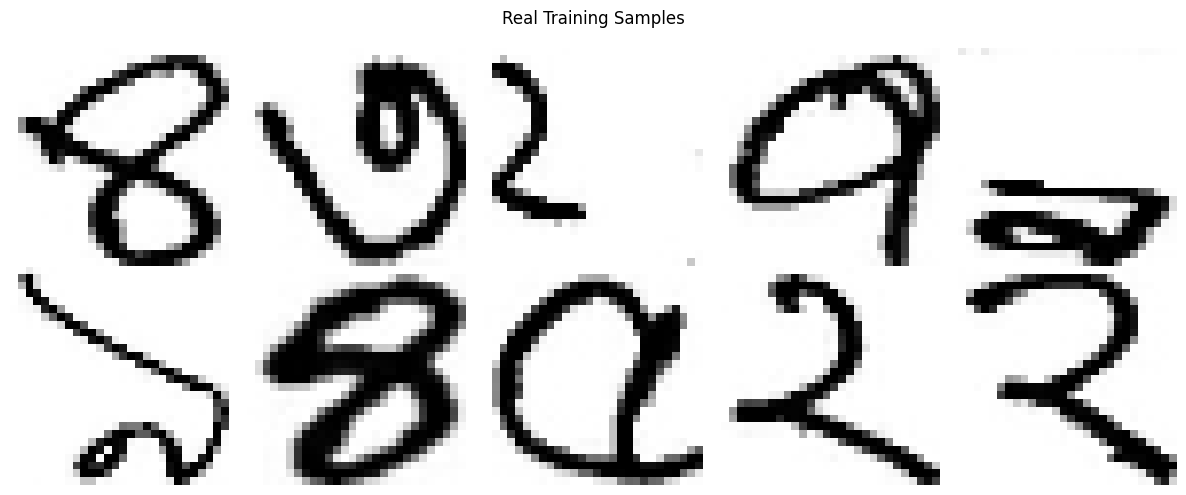

In [8]:
import matplotlib.pyplot as plt

for batch in dataset.take(1):
    print(f"Batch shape : {batch.shape}")
    print(f"Min / Max   : {tf.reduce_min(batch).numpy():.4f} / {tf.reduce_max(batch).numpy():.4f}")
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for ax, img in zip(axes.flatten(), batch[:10]):
        ax.imshow(img.numpy().squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle("Real Training Samples")
    plt.tight_layout()
    plt.show()

# Build Generator

In [9]:
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(HIDDEN_DIM, input_dim=LATENT_DIM, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(HIDDEN_DIM * 2, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(HIDDEN_DIM * 4, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(IMG_FLAT),
        tf.keras.layers.Activation('tanh'),
        tf.keras.layers.Reshape((IMG_SIZE, IMG_SIZE, 1))
    ])
    return model

# Build Discriminator

In [10]:
def build_discriminator():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 1)),
        tf.keras.layers.Dense(HIDDEN_DIM * 2),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(HIDDEN_DIM),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1)
    ])
    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
generator     = build_generator()
discriminator = build_discriminator()

optimizer_G = tf.keras.optimizers.Adam(learning_rate=LR_G, beta_1=0.5, beta_2=0.999)
optimizer_D = tf.keras.optimizers.Adam(learning_rate=LR_D, beta_1=0.5, beta_2=0.999)

criterion = tf.keras.losses.BinaryCrossentropy(from_logits=True)

fixed_noise = tf.random.normal([25, LATENT_DIM])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
history = {'epoch': [], 'loss_D': [], 'loss_G': [], 'D_x': [], 'D_G_z1': [], 'D_G_z2': []}

def sample(epoch, loss_D, loss_G):
    imgs = generator(fixed_noise, training=False).numpy()
    imgs = (imgs + 1) / 2
    imgs = imgs.clip(0, 1)
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    fig.patch.set_facecolor('#0d0d0d')
    for ax, img in zip(axes.flatten(), imgs):
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')
    fig.suptitle(
        f'Epoch {epoch}/{EPOCHS}   |   Loss_D: {loss_D:.4f}   |   Loss_G: {loss_G:.4f}',
        color='white', fontsize=13, fontweight='bold', y=0.98
    )
    plt.tight_layout()
    plt.savefig(f'samples_epoch_{epoch:03d}.png', dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print()



def print_table():
    rows = list(zip(
        history['epoch'], history['loss_D'], history['loss_G'],
        history['D_x'], history['D_G_z1'], history['D_G_z2']
    ))
    rows = rows[-10:]
    rows = [[e, f'{ld:.4f}', f'{lg:.4f}', f'{dx:.4f}',
             f'{dg1:.4f}', f'{dg2:.4f}'] for e, ld, lg, dx, dg1, dg2 in rows]
    print(tabulate(
        rows,
        headers=['Epoch', 'Loss_D', 'Loss_G', 'D(x)', 'D(G(z1))', 'D(G(z2))'],
        tablefmt='fancy_grid',
        numalign='center'
    ))

In [13]:
@tf.function
def train_step(real_imgs):
    bs = tf.shape(real_imgs)[0]
    real_labels = tf.ones((bs, 1)) * 0.9   # label smoothing
    fake_labels = tf.zeros((bs, 1))

    # --- Discriminator step ---
    z = tf.random.normal([bs, LATENT_DIM])
    with tf.GradientTape() as tape_D:
        fake_imgs  = generator(z, training=False)   # no grad for G here
        D_real     = discriminator(real_imgs, training=True)
        D_fake     = discriminator(fake_imgs, training=True)
        loss_D     = (criterion(real_labels, D_real) +
                      criterion(fake_labels, D_fake)) / 2
    grads_D = tape_D.gradient(loss_D, discriminator.trainable_variables)
    optimizer_D.apply_gradients(zip(grads_D, discriminator.trainable_variables))

    # --- Generator step (ONCE) ---
    z = tf.random.normal([bs, LATENT_DIM])
    with tf.GradientTape() as tape_G:
        fake_imgs2 = generator(z, training=True)
        D_fake2    = discriminator(fake_imgs2, training=False)  # freeze D
        loss_G     = criterion(tf.ones((bs, 1)), D_fake2)
    grads_G = tape_G.gradient(loss_G, generator.trainable_variables)
    optimizer_G.apply_gradients(zip(grads_G, generator.trainable_variables))

    return (
        loss_D,
        loss_G,
        tf.reduce_mean(tf.sigmoid(D_real)),
        tf.reduce_mean(tf.sigmoid(D_fake)),
        tf.reduce_mean(tf.sigmoid(D_fake2))
    )

In [14]:
def train():
    print("=" * 70)
    print(f"  Vanilla GAN — Bengali Digits | Device: {'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'}")
    print(f"  Epochs: {EPOCHS} | Batch Size: {BATCH_SIZE} | LR_G: {LR_G} | LR_D: {LR_D}")
    print("=" * 70)
    print()

    epoch_pbar = tqdm(
        range(1, EPOCHS + 1),
        desc="Training Progress",
        unit="epoch",
        colour="green",
        position=0,
        leave=True,
        dynamic_ncols=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"
    )

    for epoch in epoch_pbar:
        sum_loss_D = sum_loss_G = 0.0
        sum_D_x = sum_D_G_z1 = sum_D_G_z2 = 0.0
        n_batches = 0
        start = time.time()

        batch_pbar = tqdm(
            dataset,
            desc=f"Epoch {epoch:3d}",
            unit="batch",
            colour="cyan",
            position=1,
            leave=False,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
        )

        for real_imgs in batch_pbar:
            loss_D, loss_G, D_x, D_G_z1, D_G_z2 = train_step(real_imgs)

            sum_loss_D += loss_D.numpy()
            sum_loss_G += loss_G.numpy()
            sum_D_x    += D_x.numpy()
            sum_D_G_z1 += D_G_z1.numpy()
            sum_D_G_z2 += D_G_z2.numpy()
            n_batches  += 1

            batch_pbar.set_postfix({
                'Loss_D' : f'{loss_D.numpy():.4f}',
                'Loss_G' : f'{loss_G.numpy():.4f}',
                'D(x)'   : f'{D_x.numpy():.4f}',
                'D(G(z))': f'{D_G_z2.numpy():.4f}'
            })

        avg_loss_D = sum_loss_D / n_batches
        avg_loss_G = sum_loss_G / n_batches
        avg_D_x    = sum_D_x    / n_batches
        avg_D_G_z1 = sum_D_G_z1 / n_batches
        avg_D_G_z2 = sum_D_G_z2 / n_batches
        elapsed    = time.time() - start

        history['epoch'].append(epoch)
        history['loss_D'].append(avg_loss_D)
        history['loss_G'].append(avg_loss_G)
        history['D_x'].append(avg_D_x)
        history['D_G_z1'].append(avg_D_G_z1)
        history['D_G_z2'].append(avg_D_G_z2)

        epoch_pbar.set_postfix({
            'Loss_D': f'{avg_loss_D:.4f}',
            'Loss_G': f'{avg_loss_G:.4f}',
            'D(x)'  : f'{avg_D_x:.4f}',
            'Time'  : f'{elapsed:.1f}s'
        })

        clear_output(wait=True)
        print_table()
        sample(epoch, avg_loss_D, avg_loss_G)

    print("\nTraining complete!")



╒═════════╤══════════╤══════════╤════════╤════════════╤════════════╕
│  Epoch  │  Loss_D  │  Loss_G  │  D(x)  │  D(G(z1))  │  D(G(z2))  │
╞═════════╪══════════╪══════════╪════════╪════════════╪════════════╡
│   191   │  0.5413  │  1.7019  │ 0.5978 │   0.3053   │   0.1977   │
├─────────┼──────────┼──────────┼────────┼────────────┼────────────┤
│   192   │  0.552   │  1.7039  │ 0.595  │   0.3108   │   0.197    │
├─────────┼──────────┼──────────┼────────┼────────────┼────────────┤
│   193   │  0.552   │  1.6933  │ 0.5912 │   0.3121   │   0.1987   │
├─────────┼──────────┼──────────┼────────┼────────────┼────────────┤
│   194   │  0.541   │  1.7012  │ 0.6007 │   0.3027   │   0.1979   │
├─────────┼──────────┼──────────┼────────┼────────────┼────────────┤
│   195   │  0.5574  │  1.7069  │ 0.5842 │   0.3141   │   0.1958   │
├─────────┼──────────┼──────────┼────────┼────────────┼────────────┤
│   196   │  0.5505  │  1.6737  │ 0.5916 │   0.3102   │   0.2031   │
├─────────┼──────────┼──────────┼─

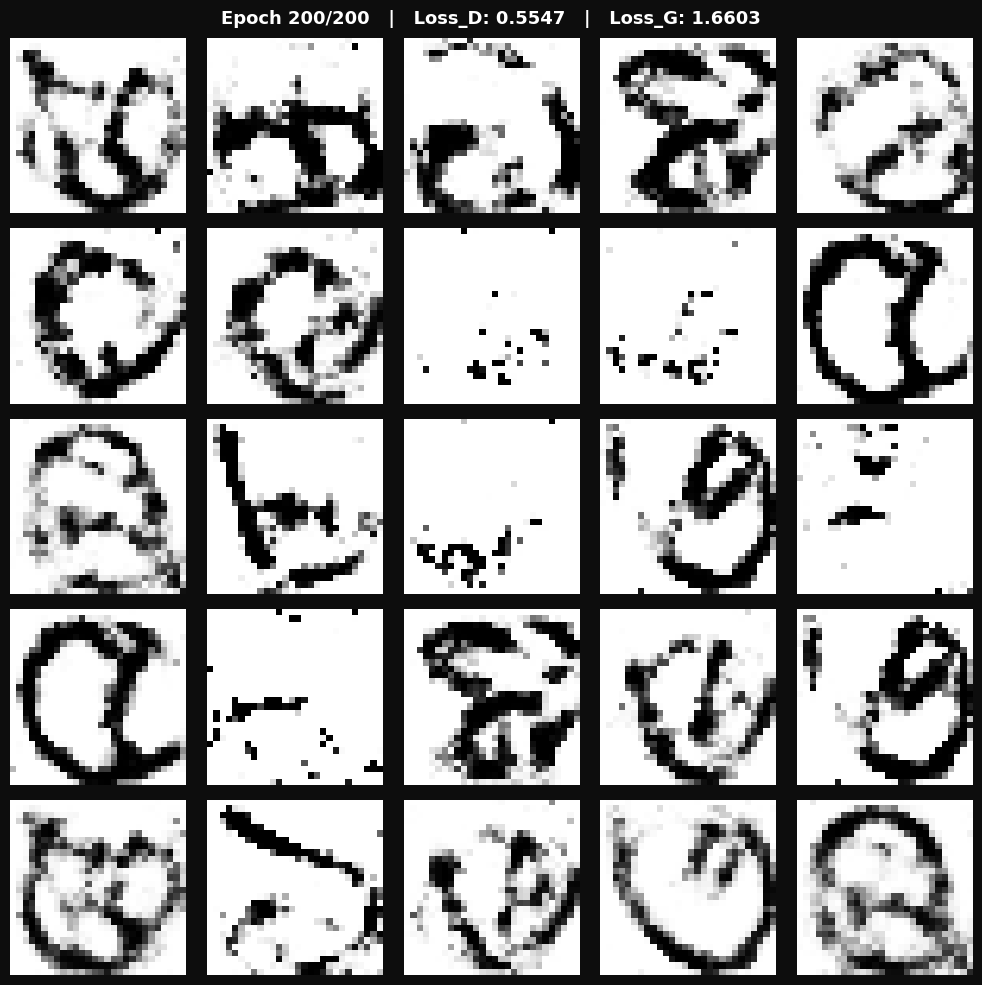



Training complete!


In [15]:
train()

In [16]:
def plot_training_history():
    epochs = history['epoch']
    loss_D = history['loss_D']
    loss_G = history['loss_G']
    D_x = history['D_x']
    D_G_z1 = history['D_G_z1']
    D_G_z2 = history['D_G_z2']

    plt.style.use('dark_background')
    fig = plt.figure(figsize=(18, 12))
    fig.patch.set_facecolor('#0a0a0a')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    COLORS = {
        'D':    '#f4a261',
        'G':    '#2ec4b6',
        'Dx':   '#e9c46a',
        'DGz1': '#e76f51',
        'DGz2': '#a8dadc',
        'grid': '#1c1c1c',
        'text': '#f1faee',
    }

    def style_ax(ax, title):
        ax.set_facecolor('#0f0f0f')
        ax.set_title(title, color=COLORS['text'], fontsize=11, fontweight='bold', pad=10,
                     fontfamily='monospace')
        ax.tick_params(colors='#888888', labelsize=8)
        ax.xaxis.label.set_color('#888888')
        ax.yaxis.label.set_color('#888888')
        for spine in ax.spines.values():
            spine.set_edgecolor('#2a2a2a')
        ax.grid(color=COLORS['grid'], linestyle='--', linewidth=0.5, alpha=0.8)
        ax.set_xlabel('Epoch', fontsize=9, fontfamily='monospace')

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, loss_D, color=COLORS['D'], linewidth=2, label='Loss_D', marker='s', markersize=3)
    ax1.plot(epochs, loss_G, color=COLORS['G'], linewidth=2, label='Loss_G', marker='s', markersize=3)
    ax1.fill_between(epochs, loss_D, alpha=0.08, color=COLORS['D'])
    ax1.fill_between(epochs, loss_G, alpha=0.08, color=COLORS['G'])
    ax1.axhline(y=0.693, color='#555555', linestyle=':', linewidth=1, label='Nash Eq (ln2)')
    ax1.set_ylabel('Loss', fontsize=9, fontfamily='monospace')
    ax1.legend(fontsize=8, facecolor='#141414', edgecolor='#2a2a2a', labelcolor=COLORS['text'],
               prop={'family': 'monospace'})
    style_ax(ax1, 'Generator & Discriminator Loss')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, D_x, color=COLORS['Dx'], linewidth=2, marker='s', markersize=3, label='D(x)')
    ax2.fill_between(epochs, D_x, alpha=0.12, color=COLORS['Dx'])
    ax2.axhline(y=0.5, color='#555555', linestyle=':', linewidth=1, label='Ideal = 0.5')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Probability', fontsize=9, fontfamily='monospace')
    ax2.legend(fontsize=8, facecolor='#141414', edgecolor='#2a2a2a', labelcolor=COLORS['text'],
               prop={'family': 'monospace'})
    style_ax(ax2, 'D(x) - Real Image Confidence')

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(epochs, D_G_z1, color=COLORS['DGz1'], linewidth=2, marker='s', markersize=3, label='D(G(z)) before')
    ax3.plot(epochs, D_G_z2, color=COLORS['DGz2'], linewidth=2, marker='s', markersize=3, label='D(G(z)) after')
    ax3.fill_between(epochs, D_G_z1, alpha=0.08, color=COLORS['DGz1'])
    ax3.fill_between(epochs, D_G_z2, alpha=0.08, color=COLORS['DGz2'])
    ax3.axhline(y=0.5, color='#555555', linestyle=':', linewidth=1, label='Ideal = 0.5')
    ax3.set_ylim(0, 1)
    ax3.set_ylabel('Probability', fontsize=9, fontfamily='monospace')
    ax3.legend(fontsize=8, facecolor='#141414', edgecolor='#2a2a2a', labelcolor=COLORS['text'],
               prop={'family': 'monospace'})
    style_ax(ax3, 'D(G(z)) Before & After G Update')

    ax4 = fig.add_subplot(gs[1, 0])
    diff = [g - d for g, d in zip(loss_G, loss_D)]
    bar_colors = [COLORS['G'] if v > 0 else COLORS['D'] for v in diff]
    ax4.bar(epochs, diff, color=bar_colors, alpha=0.75, width=0.6)
    ax4.axhline(y=0, color='#555555', linestyle='-', linewidth=0.8)
    ax4.set_ylabel('Loss_G - Loss_D', fontsize=9, fontfamily='monospace')
    style_ax(ax4, 'Loss Gap (G - D)')

    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(epochs, D_x, color=COLORS['Dx'], linewidth=2, label='D(x) real', marker='s', markersize=3)
    ax5.plot(epochs, D_G_z2, color=COLORS['DGz2'], linewidth=2, label='D(G(z)) fake', marker='s', markersize=3)
    ax5.fill_between(epochs, D_x, D_G_z2, alpha=0.06, color='#ffffff', label='Gap')
    ax5.axhline(y=0.5, color='#555555', linestyle=':', linewidth=1)
    ax5.set_ylim(0, 1)
    ax5.set_ylabel('Probability', fontsize=9, fontfamily='monospace')
    ax5.legend(fontsize=8, facecolor='#141414', edgecolor='#2a2a2a', labelcolor=COLORS['text'],
               prop={'family': 'monospace'})
    style_ax(ax5, 'Real vs Fake Confidence Gap')

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    ax6.set_facecolor('#0f0f0f')

    final_loss_D = loss_D[-1]
    final_loss_G = loss_G[-1]
    final_Dx     = D_x[-1]
    final_DGz    = D_G_z2[-1]
    balance      = abs(final_Dx - final_DGz)

    def health(val, good, warn):
        if val <= good: return 'Good'
        if val <= warn: return 'Warn'
        return 'Bad'

    rows = [
        ['Loss_D (final)',    f'{final_loss_D:.4f}', health(final_loss_D, 0.5, 0.9)],
        ['Loss_G (final)',    f'{final_loss_G:.4f}', health(final_loss_G, 1.5, 3.0)],
        ['D(x) (final)',      f'{final_Dx:.4f}',     'Good' if 0.4 < final_Dx  < 0.8 else 'Warn'],
        ['D(G(z)) (final)',   f'{final_DGz:.4f}',    'Good' if 0.2 < final_DGz < 0.6 else 'Warn'],
        ['Real/Fake Balance', f'{balance:.4f}',       'Good' if balance < 0.3 else 'Bad'],
        ['Total Epochs',      f'{epochs[-1]}',        'Done'],
    ]

    status_colors = {'Good': '#2ec4b6', 'Warn': '#e9c46a', 'Bad': '#e76f51', 'Done': '#a8dadc'}

    table = ax6.table(
        cellText=rows,
        colLabels=['Metric', 'Value', 'Status'],
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    for (r, c), cell in table.get_celld().items():
        cell.set_facecolor('#161616' if r % 2 == 0 else '#0f0f0f')
        cell.set_edgecolor('#2a2a2a')
        if r == 0:
            cell.set_facecolor('#1e1e1e')
            cell.set_text_props(color=COLORS['text'], fontweight='bold',
                                fontfamily='monospace')
        elif c == 2 and r > 0:
            status = rows[r - 1][2]
            cell.set_text_props(color=status_colors.get(status, COLORS['text']),
                                fontfamily='monospace', fontweight='bold')
        else:
            cell.set_text_props(color='#cccccc', fontfamily='monospace')

    style_ax(ax6, 'Training Health Summary')

    fig.suptitle(
        'Vanilla GAN  |  Training Report',
        color=COLORS['text'], fontsize=14, fontweight='bold', y=1.01,
        fontfamily='monospace'
    )

    plt.savefig('gan_training_report.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
    plt.show()
    print("Saved -> gan_training_report.png")

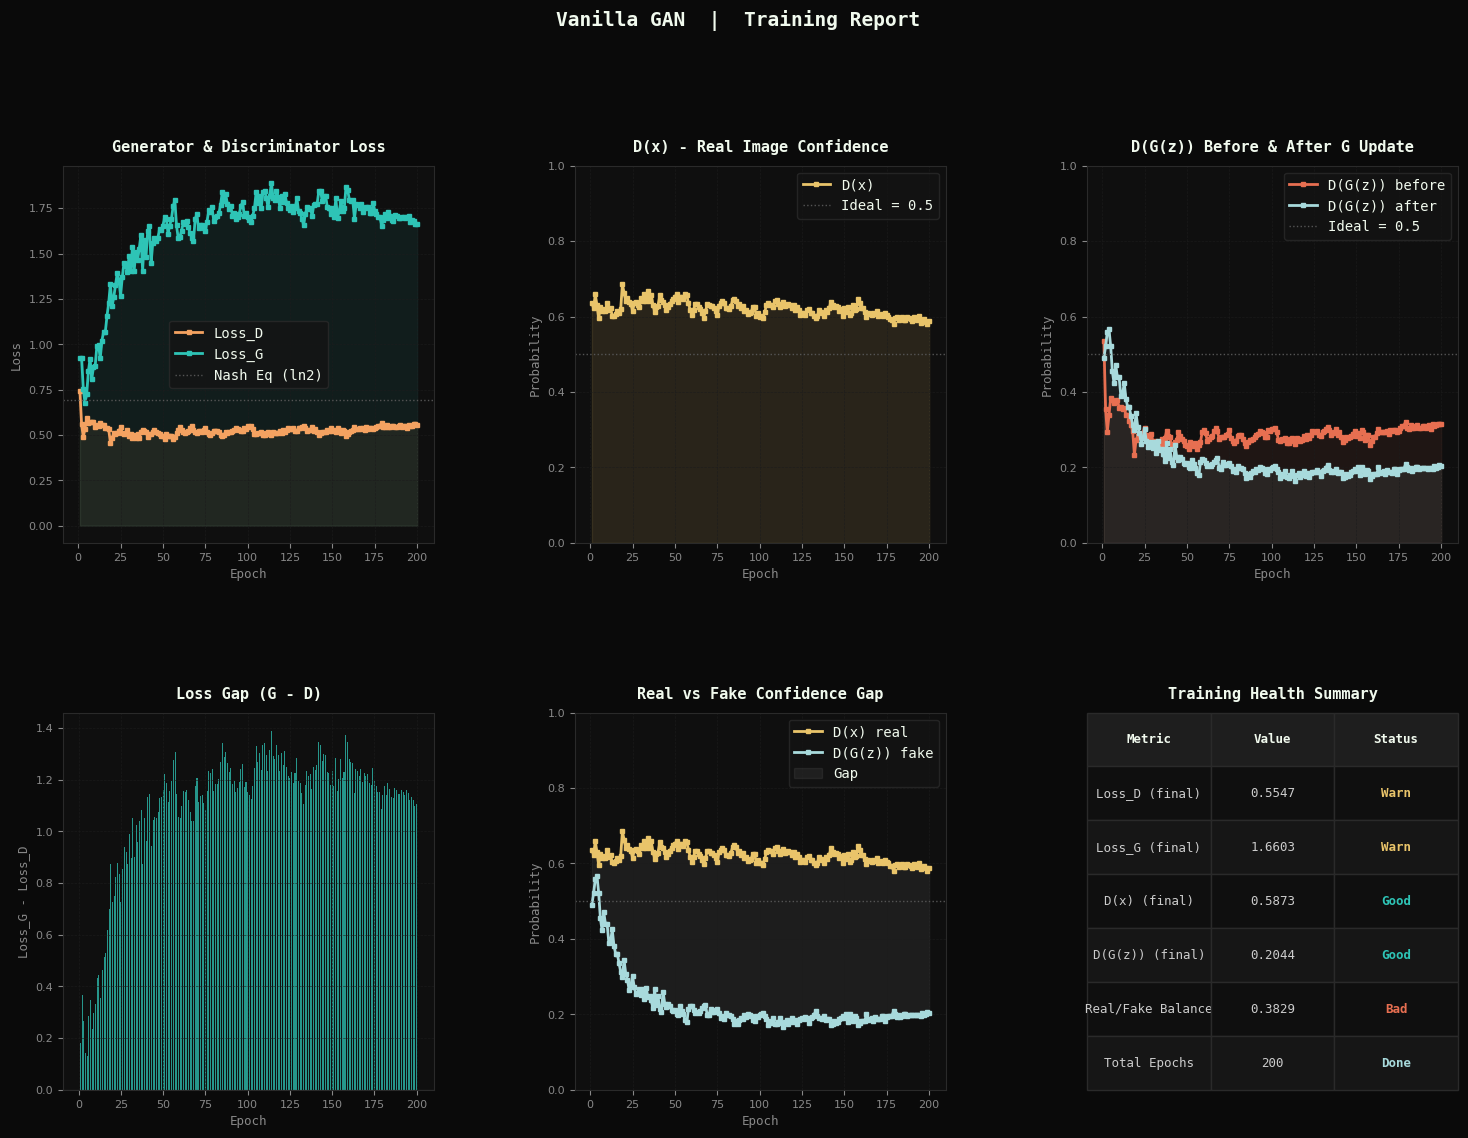

Saved -> gan_training_report.png


In [17]:
plot_training_history()

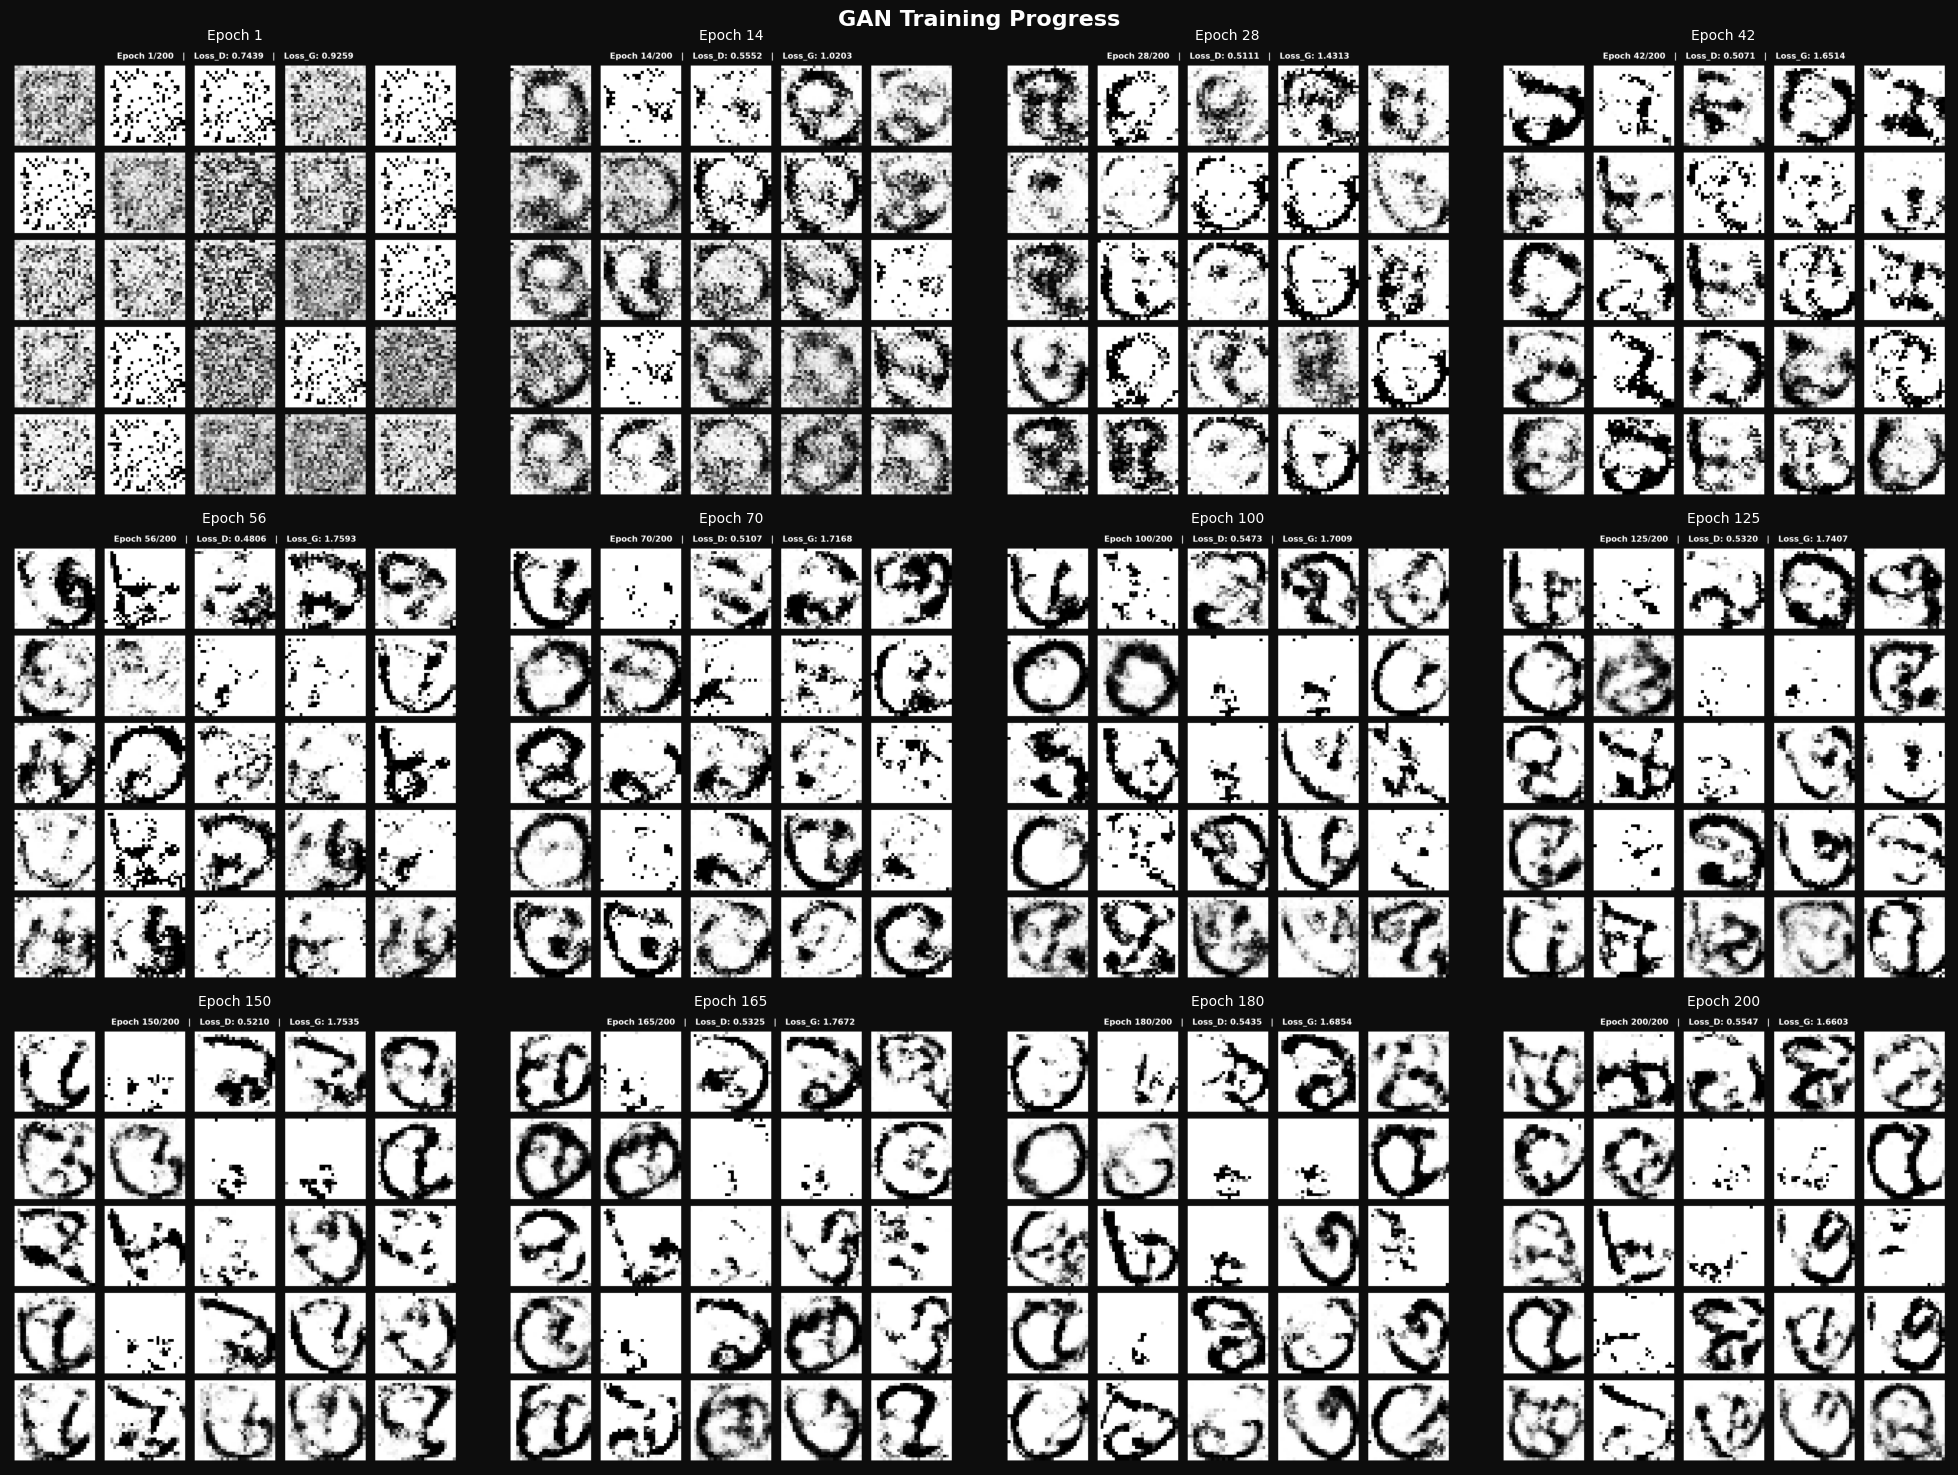

In [18]:
import glob

saved = sorted(glob.glob("samples_epoch_*.png"))

epochs_to_show = [1, 14, 28, 42, 56, 70, 100, 125, 150, 165, 180, 200]
files = [f for f in saved if int(f.split('_')[-1].replace('.png', '')) in epochs_to_show]
files = files if files else saved[::max(1, len(saved)//12)][:12]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.patch.set_facecolor('#0d0d0d')

for ax, fpath in zip(axes.flatten(), files):
    epoch_num = int(fpath.split('_')[-1].replace('.png', ''))
    img = plt.imread(fpath)
    ax.imshow(img)
    ax.set_title(f'Epoch {epoch_num}', color='white', fontsize=10)
    ax.axis('off')

for ax in axes.flatten()[len(files):]:
    ax.axis('off')

plt.suptitle("GAN Training Progress", color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
REAL_SAMPLES = 1000
FAKE_SAMPLES = 1000
BATCH_SIZE_M = 64

def get_real_images(dataset, n):
    imgs = []
    pbar = tqdm(total=n, desc="Loading real images", unit="img", colour="green")
    for batch in dataset:
        imgs.append(batch.numpy())
        pbar.update(len(batch))
        if sum(len(x) for x in imgs) >= n:
            break
    pbar.close()
    return np.concatenate(imgs, axis=0)[:n]

def generate_fake_images(n):
    imgs = []
    for i in tqdm(range(0, n, BATCH_SIZE_M), desc="Generating fake images", unit="batch", colour="cyan"):
        z = tf.random.normal([min(BATCH_SIZE_M, n - i), LATENT_DIM])
        fake = generator(z, training=False).numpy()
        imgs.append(fake)
    return np.concatenate(imgs, axis=0)[:n]

def to_uint8_rgb(imgs):
    imgs = ((imgs + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    if imgs.shape[-1] == 1:
        imgs = np.repeat(imgs, 3, axis=-1)
    return imgs

def get_inception_model():
    inception = tf.keras.applications.InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))
    return inception

def preprocess_for_inception(imgs):
    imgs = tf.image.resize(imgs, [299, 299])
    imgs = tf.keras.applications.inception_v3.preprocess_input(imgs)
    return imgs.numpy()

def get_inception_features(imgs, model, desc="Extracting inception features"):
    features = []
    for i in tqdm(range(0, len(imgs), BATCH_SIZE_M), desc=desc, unit="batch", colour="yellow"):
        batch = preprocess_for_inception(imgs[i:i + BATCH_SIZE_M].astype(np.float32))
        feat = model.predict(batch, verbose=0)
        features.append(feat)
    return np.concatenate(features, axis=0)

def compute_fid(real_feats, fake_feats):
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

def compute_kid(real_feats, fake_feats, subset=1000):
    n = min(subset, len(real_feats), len(fake_feats))
    real = real_feats[:n]
    fake = fake_feats[:n]
    k_rr = polynomial_kernel(real, real, degree=3, coef0=1, gamma=None)
    k_ff = polynomial_kernel(fake, fake, degree=3, coef0=1, gamma=None)
    k_rf = polynomial_kernel(real, fake, degree=3, coef0=1, gamma=None)
    kid = (k_rr.mean() + k_ff.mean() - 2 * k_rf.mean())
    return float(kid), 0.0

def compute_inception_score(imgs, model, splits=10):
    preds = []
    for i in tqdm(range(0, len(imgs), BATCH_SIZE_M), desc="Computing Inception Score", unit="batch", colour="magenta"):
        batch = preprocess_for_inception(imgs[i:i + BATCH_SIZE_M].astype(np.float32))
        p = model.predict(batch, verbose=0)
        preds.append(tf.nn.softmax(p).numpy())
    preds = np.concatenate(preds, axis=0)
    scores = []
    n = len(preds)
    split = n // splits
    for k in range(splits):
        part = preds[k * split:(k + 1) * split]
        py = part.mean(axis=0)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        scores.append(np.exp(kl.sum(axis=1).mean()))
    return float(np.mean(scores)), float(np.std(scores))

def compute_ssim(real_imgs, fake_imgs, n=200):
    scores = []
    for i in tqdm(range(min(n, len(real_imgs), len(fake_imgs))), desc="Computing SSIM", unit="img", colour="blue"):
        r = real_imgs[i].squeeze()
        f = fake_imgs[i].squeeze()
        scores.append(ssim(r, f, data_range=1.0))
    return float(np.mean(scores)), float(np.std(scores))

def compute_msssim(real_imgs, fake_imgs, n=200):
    scores = []
    for i in tqdm(range(min(n, len(real_imgs), len(fake_imgs))), desc="Computing MS-SSIM", unit="img", colour="blue"):
        r = tf.constant(real_imgs[i:i+1].transpose(0,3,1,2), dtype=tf.float32)
        f = tf.constant(fake_imgs[i:i+1].transpose(0,3,1,2), dtype=tf.float32)
        try:
            val = tf.image.ssim_multiscale(tf.transpose(r, [0,2,3,1]), tf.transpose(f, [0,2,3,1]), max_val=1.0).numpy()[0]
            scores.append(float(val))
        except:
            scores.append(0.0)
    return float(np.mean(scores)), float(np.std(scores))

def compute_lpips(real_imgs, fake_imgs, n=200):
    loss_fn = lpips.LPIPS(net='alex')
    scores = []
    min_size = 64
    for i in tqdm(range(min(n, len(real_imgs), len(fake_imgs))), desc="Computing LPIPS", unit="img", colour="red"):
        r = real_imgs[i]
        f = fake_imgs[i]
        if r.shape[0] < min_size or r.shape[1] < min_size:
            r = tf.image.resize(r[np.newaxis], [min_size, min_size]).numpy()[0]
            f = tf.image.resize(f[np.newaxis], [min_size, min_size]).numpy()[0]
        r = torch.tensor(r.transpose(2, 0, 1)).unsqueeze(0).float() * 2 - 1
        f = torch.tensor(f.transpose(2, 0, 1)).unsqueeze(0).float() * 2 - 1
        with torch.no_grad():
            scores.append(loss_fn(r, f).item())
    return float(np.mean(scores))

def compute_discriminator_accuracy(real_imgs, fake_imgs):
    real_t = tf.constant(real_imgs, dtype=tf.float32)
    fake_t = tf.constant(fake_imgs, dtype=tf.float32)
    real_out = tf.sigmoid(discriminator(real_t, training=False)).numpy()
    fake_out = tf.sigmoid(discriminator(fake_t, training=False)).numpy()
    real_acc = float((real_out >= 0.5).mean() * 100)
    fake_acc = float((fake_out < 0.5).mean() * 100)
    overall = float(((real_out >= 0.5).sum() + (fake_out < 0.5).sum()) / (len(real_out) + len(fake_out)) * 100)
    return real_acc, fake_acc, overall

def compute_precision_recall(real_feats, fake_feats, k=3):
    from sklearn.neighbors import NearestNeighbors
    nbrs_real = NearestNeighbors(n_neighbors=k+1).fit(real_feats)
    nbrs_fake = NearestNeighbors(n_neighbors=k+1).fit(fake_feats)
    real_dist, _ = nbrs_real.kneighbors(real_feats)
    fake_dist, _ = nbrs_fake.kneighbors(fake_feats)
    real_r = real_dist[:, -1]
    fake_r = fake_dist[:, -1]
    dists = nbrs_real.kneighbors(fake_feats, n_neighbors=k+1)[0][:, -1]
    prec = float((dists <= real_r[:len(dists)]).mean())
    dists2 = nbrs_fake.kneighbors(real_feats, n_neighbors=k+1)[0][:, -1]
    rec = float((dists2 <= fake_r[:len(dists2)]).mean())
    return prec, rec

def compute_all_metrics():
    print("Computing metrics...")
    real_imgs_raw = get_real_images(dataset, REAL_SAMPLES)
    fake_imgs_raw = generate_fake_images(FAKE_SAMPLES)
    real_imgs = ((real_imgs_raw + 1) / 2).clip(0, 1)
    fake_imgs = ((fake_imgs_raw + 1) / 2).clip(0, 1)
    real_rgb = to_uint8_rgb(real_imgs)
    fake_rgb = to_uint8_rgb(fake_imgs)

    inception = get_inception_model()
    real_feats = get_inception_features(real_rgb, inception, desc="Inception features [real]")
    fake_feats = get_inception_features(fake_rgb, inception, desc="Inception features [fake]")

    fid = compute_fid(real_feats, fake_feats)
    kid_mean, kid_std = compute_kid(real_feats, fake_feats)
    is_mean, is_std = compute_inception_score(fake_rgb, inception)
    ssim_mean, ssim_std = compute_ssim(real_imgs, fake_imgs)
    msssim_mean, msssim_std = compute_msssim(real_imgs, fake_imgs)
    lpips_score = compute_lpips(real_imgs, fake_imgs)
    real_acc, fake_acc, overall = compute_discriminator_accuracy(real_imgs_raw, fake_imgs_raw)
    precision, recall = compute_precision_recall(real_feats, fake_feats)

    metrics_table = [
        ["FID",              f"{fid:.4f}",                    "Lower is better"],
        ["KID",              f"{kid_mean:.4f}",               "~0.0 Excellent"],
        ["Inception Score",  f"{is_mean:.4f} ± {is_std:.4f}", "Higher is better"],
        ["SSIM",             f"{ssim_mean:.4f} ± {ssim_std:.4f}", "Higher is better"],
        ["MS-SSIM",          f"{msssim_mean:.4f} ± {msssim_std:.4f}", "Higher is better"],
        ["LPIPS",            f"{lpips_score:.4f}",            "Lower is better"],
        ["Precision",        f"{precision:.4f}",              "Higher is better"],
        ["Recall",           f"{recall:.4f}",                 "Higher is better"],
        ["Real Acc (%)",    f"{real_acc:.2f}",  "% of real images correctly identified as real"],
        ["Fake Acc (%)",    f"{fake_acc:.2f}",  "% of fake images correctly identified as fake"],
        ["Overall Acc (%)", f"{overall:.2f}",   "100% = perfect discriminator, ~50% = generator fooling it"],
    ]

    print("\n" + "="*60)
    print("                  GAN EVALUATION DASHBOARD")
    print("="*60)
    print(tabulate(metrics_table, headers=["Metric", "Value", "Interpretation"], tablefmt="fancy_grid", numalign="right"))
    print("="*60)

In [20]:
compute_all_metrics()

Computing metrics...


Loading real images:   0%|          | 0/1000 [00:00<?, ?img/s]

Generating fake images:   0%|          | 0/16 [00:00<?, ?batch/s]

Inception features [real]:   0%|          | 0/16 [00:00<?, ?batch/s]

I0000 00:00:1775578019.966641    4009 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-07 16:07:08.767914: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Computing LPIPS:   0%|          | 0/200 [00:00<?, ?img/s]


                  GAN EVALUATION DASHBOARD
╒═════════════════╤═════════════════╤═══════════════════════════════════════════════════════════╕
│ Metric          │ Value           │ Interpretation                                            │
╞═════════════════╪═════════════════╪═══════════════════════════════════════════════════════════╡
│ FID             │ 147.8218        │ Lower is better                                           │
├─────────────────┼─────────────────┼───────────────────────────────────────────────────────────┤
│ KID             │ 0.1497          │ ~0.0 Excellent                                            │
├─────────────────┼─────────────────┼───────────────────────────────────────────────────────────┤
│ Inception Score │ 1.0866 ± 0.0060 │ Higher is better                                          │
├─────────────────┼─────────────────┼───────────────────────────────────────────────────────────┤
│ SSIM            │ 0.0812 ± 0.1197 │ Higher is better                    

Loading real images:   0%|          | 0/25 [00:00<?, ?img/s]

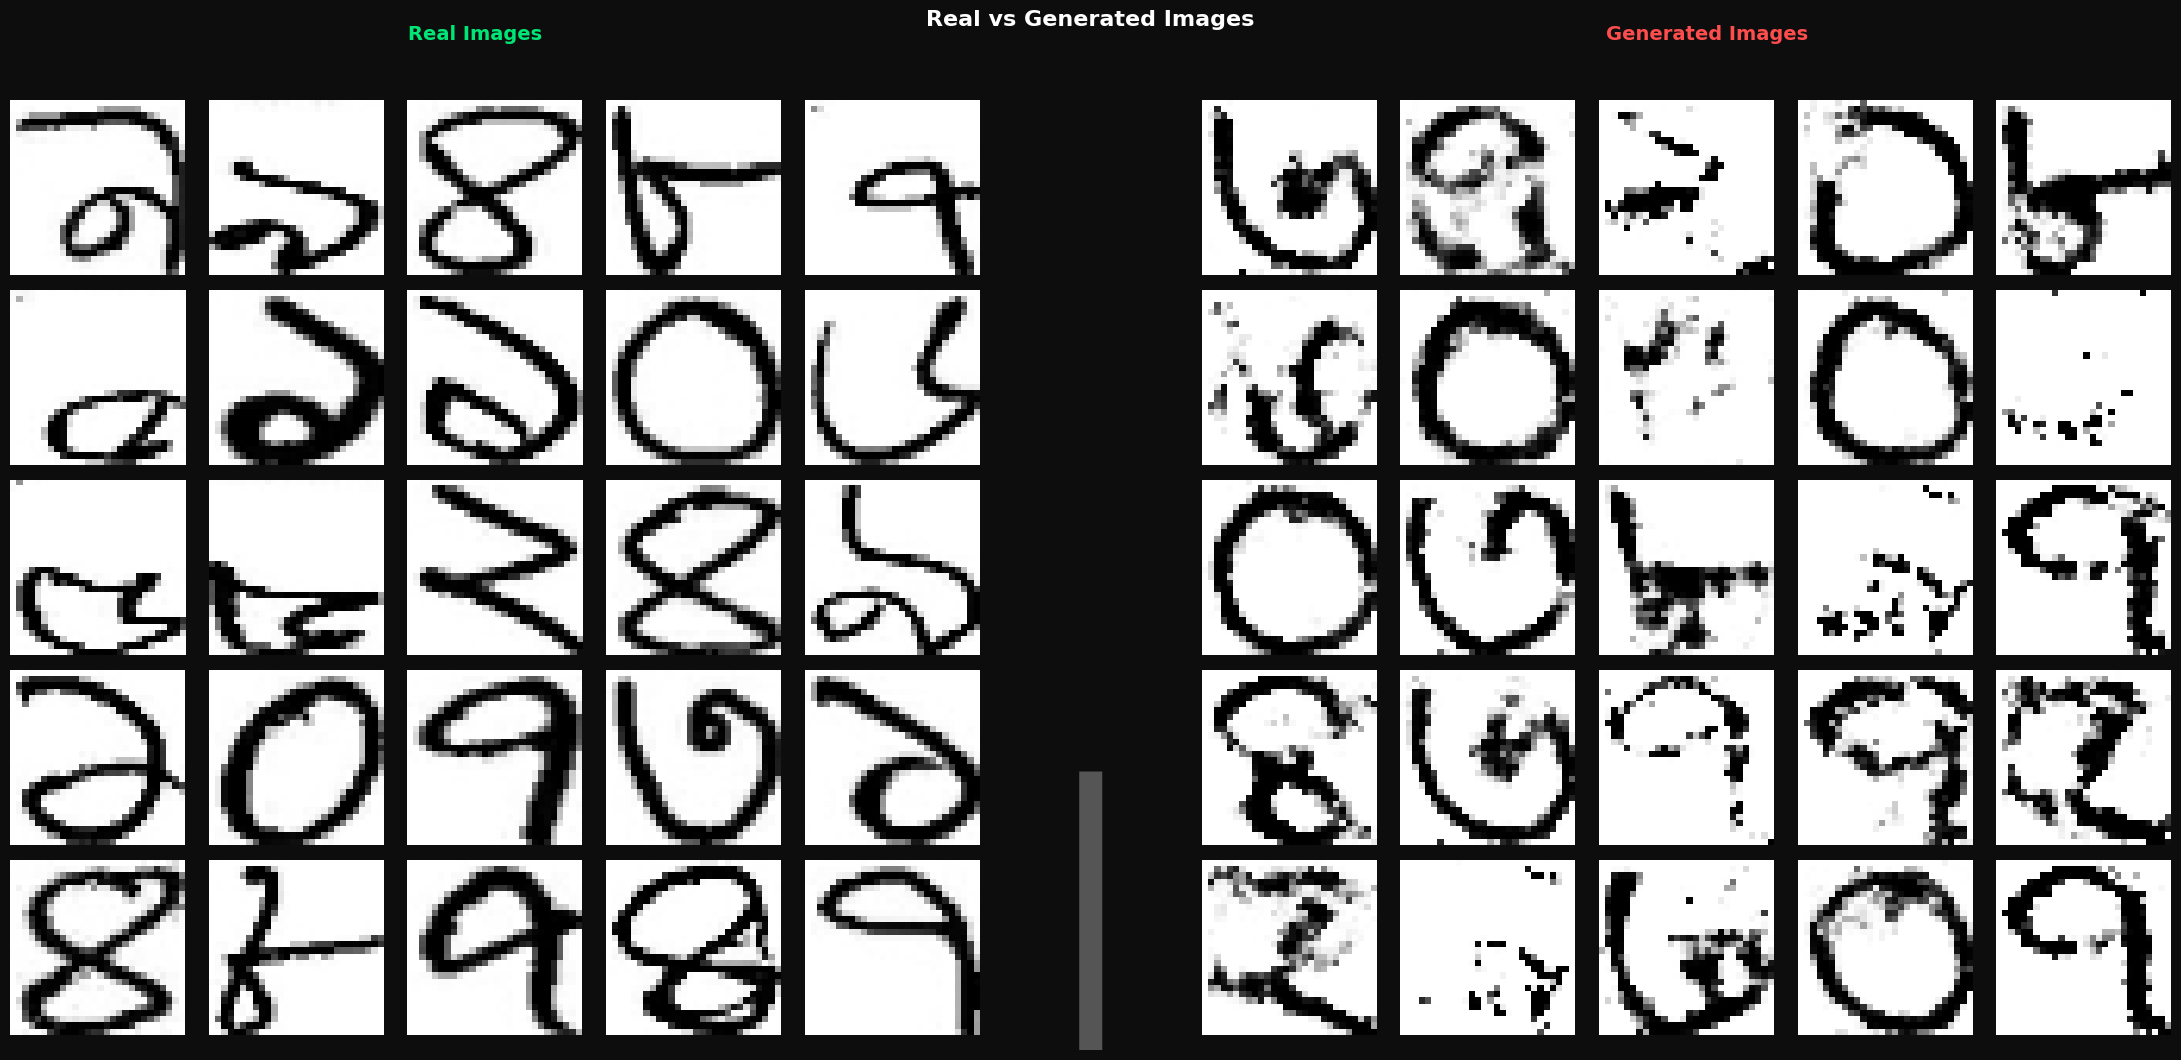

In [21]:
G = generator

z = tf.random.normal([25, LATENT_DIM])
fake_imgs = G(z, training=False).numpy()

real_imgs_sample = get_real_images(dataset, 25)

def denorm(img):
    return ((img + 1) / 2).clip(0, 1)

fig = plt.figure(figsize=(22, 10))
fig.patch.set_facecolor('#0d0d0d')

for i in range(25):
    ax = fig.add_subplot(5, 11, (i // 5) * 11 + (i % 5) + 1)
    real = denorm(real_imgs_sample[i]).squeeze()
    ax.imshow(real, cmap='gray')
    ax.axis('off')

for i in range(25):
    ax = fig.add_subplot(5, 11, (i // 5) * 11 + (i % 5) + 7)
    fake = denorm(fake_imgs[i]).squeeze()
    ax.imshow(fake, cmap='gray')
    ax.axis('off')

fig.text(0.22, 1.01, 'Real Images', color='#00e676', fontsize=14, fontweight='bold', ha='center')
fig.text(0.78, 1.01, 'Generated Images', color='#ff4d4d', fontsize=14, fontweight='bold', ha='center')
fig.text(0.5, 0.0, '|', color='white', fontsize=200, ha='center', va='bottom', alpha=0.3)

plt.suptitle('Real vs Generated Images', color='white', fontsize=16, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

Loading real images:   0%|          | 0/500 [00:00<?, ?img/s]

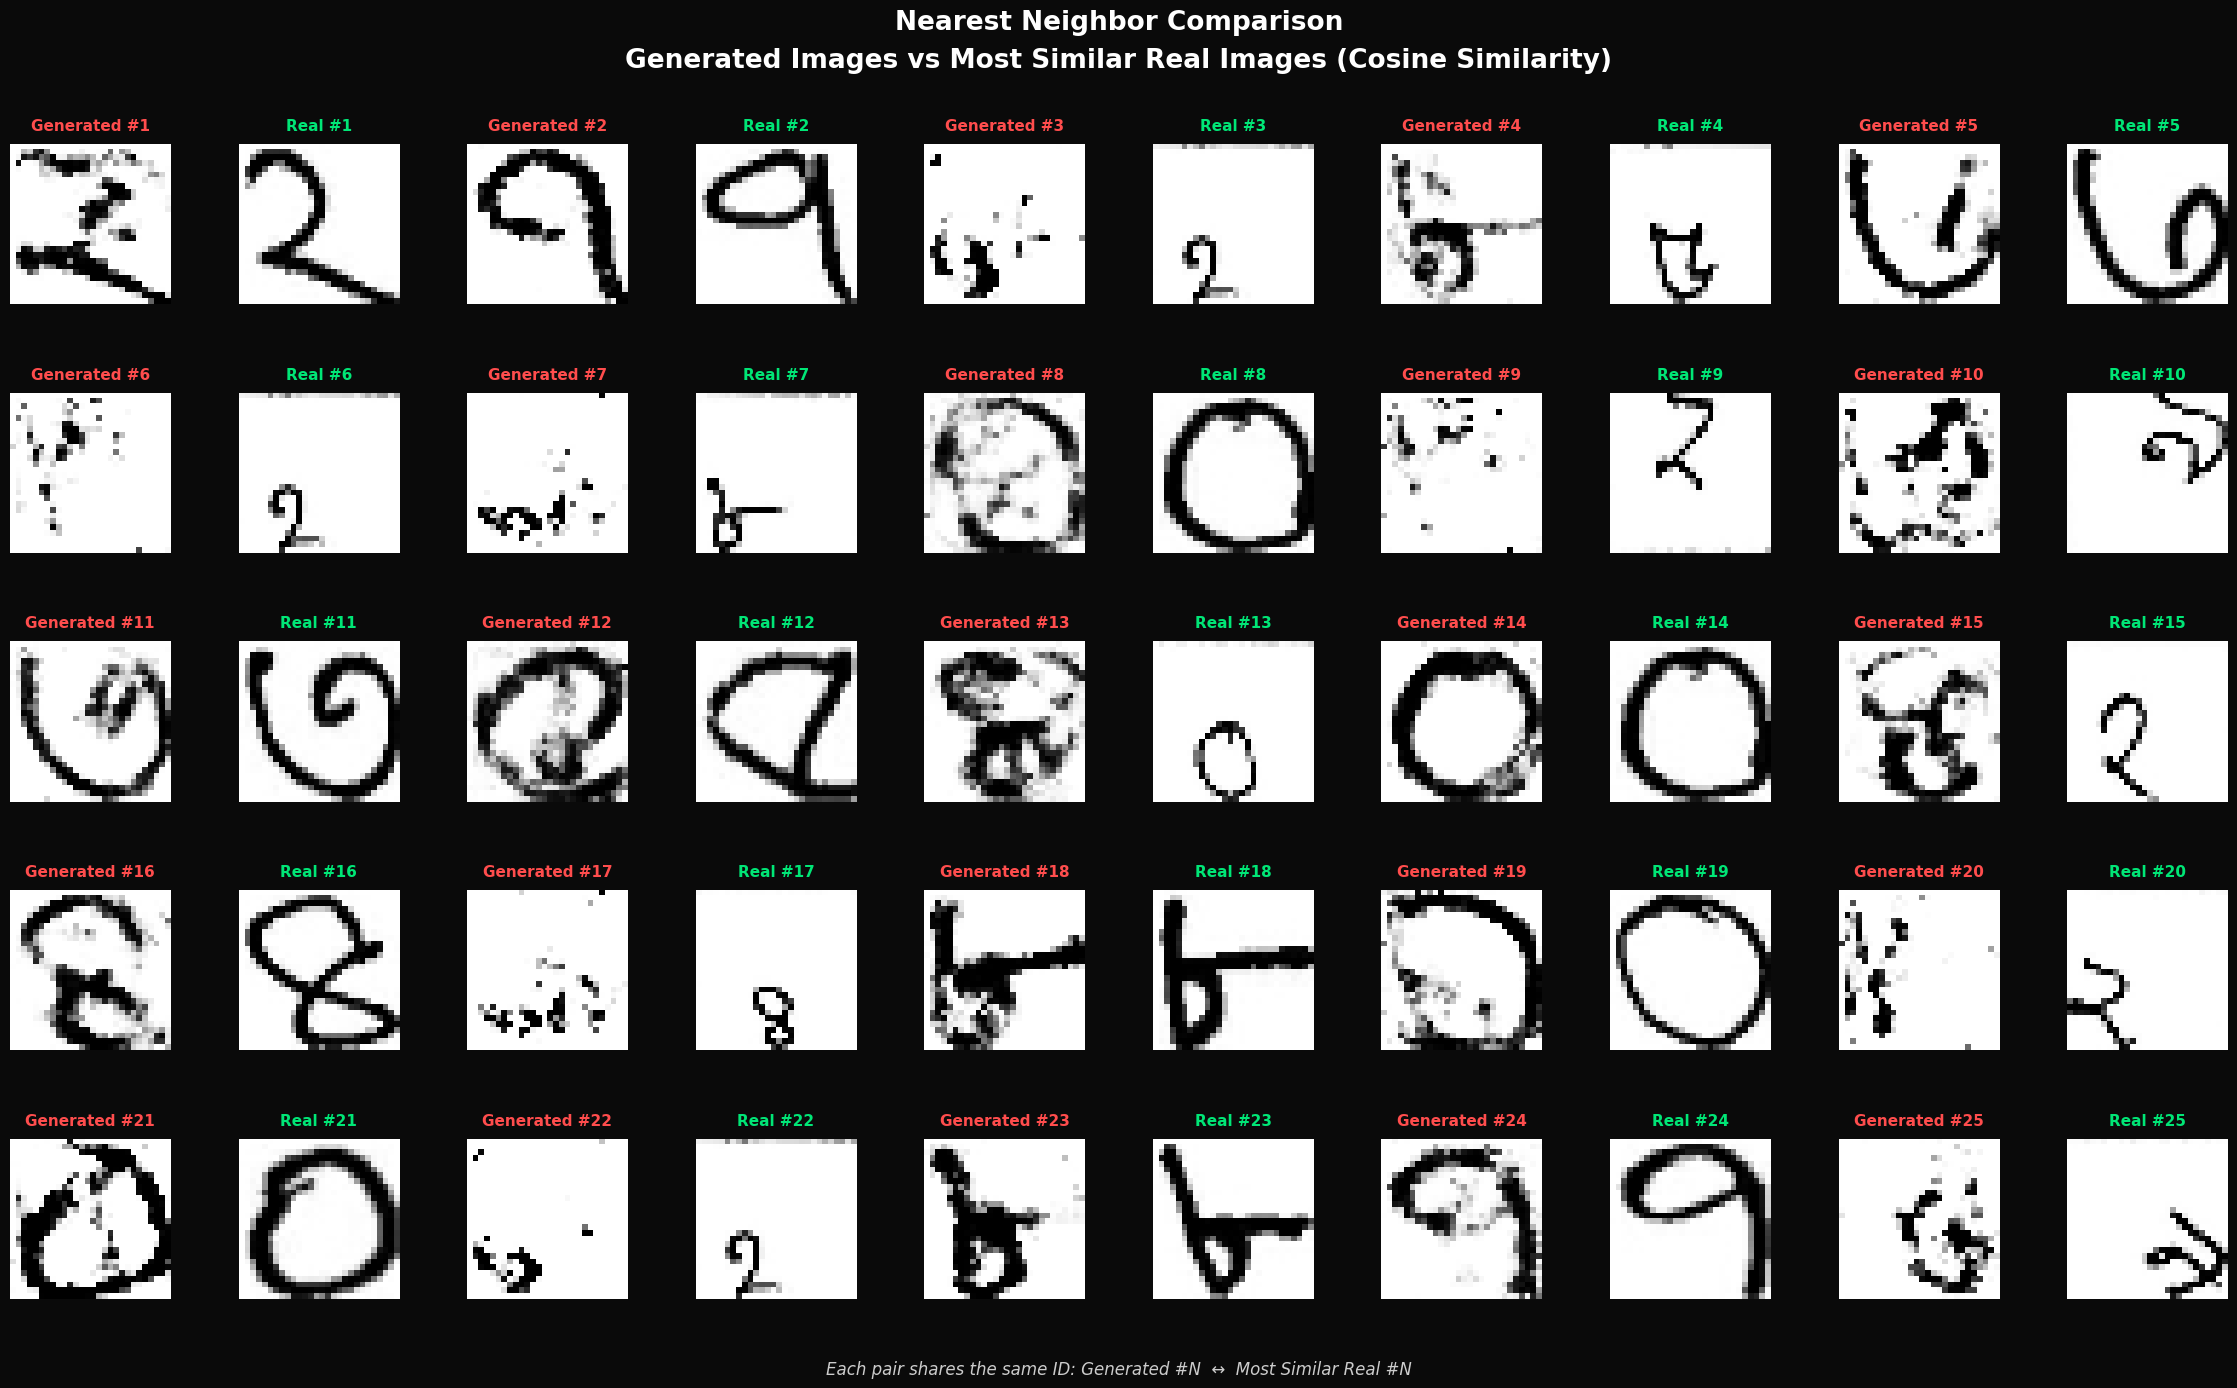

In [22]:
# Generate fake images
z = tf.random.normal([25, LATENT_DIM])
fake_imgs = generator(z, training=False).numpy()

real_imgs_sample = get_real_images(dataset, 500)

# Compute nearest neighbors
def denorm(imgs):
    return ((imgs + 1) / 2).clip(0, 1)

fake_flat = denorm(fake_imgs).reshape(25, -1)
real_flat = denorm(real_imgs_sample).reshape(500, -1)

sims = cosine_similarity(fake_flat, real_flat)
nn_indices = sims.argmax(axis=1)
nn_real = real_imgs_sample[nn_indices]

# ====================== Clean Professional Visualization ======================
fig, axes = plt.subplots(5, 10, figsize=(24, 15), facecolor='#0a0a0a')
plt.subplots_adjust(hspace=0.55, wspace=0.15, top=0.85, bottom=0.08, left=0.03, right=0.97)

for i in range(25):
    row = i // 5
    col = (i % 5) * 2
    pair_id = i + 1

    fake = denorm(fake_imgs[i]).squeeze()
    real = denorm(nn_real[i]).squeeze()

    # Generated
    ax1 = axes[row, col]
    ax1.imshow(fake, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f'Generated #{pair_id}', color='#ff4d4d', fontsize=11, fontweight='bold', pad=10)

    # Real nearest neighbor
    ax2 = axes[row, col + 1]
    ax2.imshow(real, cmap='gray')
    ax2.axis('off')
    ax2.set_title(f'Real #{pair_id}', color='#00e676', fontsize=11, fontweight='bold', pad=10)

plt.suptitle(
    'Nearest Neighbor Comparison\n'
    'Generated Images vs Most Similar Real Images (Cosine Similarity)',
    color='white',
    fontsize=19,
    fontweight='bold',
    y=0.94,
    linespacing=1.6
)

fig.text(0.5, 0.03,
         'Each pair shares the same ID: Generated #N  ↔  Most Similar Real #N',
         ha='center', fontsize=12, color='#cccccc', style='italic')

plt.show()